# Two-layer (fast episodic / slow character) strength split

**Question:** does splitting basin strength into a fast layer (high decay, tracks
current attention) and a slow layer (very low decay, only nudged via consolidation
from the fast layer) resolve the stability-plasticity tension found in
`hopfield_exploration.ipynb`?

Recap of that tension (single layer, one decay constant):
- decay=0.01 -> full erasure of early-pattern strength once attention moves on (no persistence)
- decay=0.001 -> permanent primacy lock-in, early pattern never gets caught even after
  equal later visitation (no plasticity)

**Hypothesis:** `w_char` should retain a *residual* trace of early experience (persistence)
without permanently blocking later patterns from being learned (plasticity), and should show
*savings* — faster re-strengthening on a later revisit than a pattern's original learning curve.

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [2]:
torch.manual_seed(42)
n_patterns = 5
dim = 64

X = torch.randn(n_patterns, dim, device=device)
X = F.normalize(X, dim=1)

In [3]:
def hopfield_retrieve_weighted(query, X, w, beta=4.0):
    similarities = X @ query
    biased = beta * similarities + torch.log(w)
    weights = F.softmax(biased, dim=0)
    retrieved = X.T @ weights
    return retrieved, weights

## Two-layer update rule

- `w_fast`: decay=0.02 (matches the erasure regime), increment=0.1 on each retrieval —
  moves fast, forgets fast, this is what actually drives retrieval bias moment-to-moment.
- `w_char`: decay=0.0005 (near-permanent), no direct increment from retrieval. Instead it's
  pulled toward `w_fast` slowly via a *consolidation* term — only accumulates when `w_fast`
  is sustained above baseline, i.e. repeated/consistent attention, not single visits.
- Retrieval bias combines both: `log(w_fast) + char_weight * log(w_char)`.

## Correction (2026-07-17, same session)

Jasper flagged the actual bug: the consolidation increment
`consolidation_rate * (w_fast - 1).clamp(min=0)` was flat — it didn't scale down as `w_char`
itself grew, so nothing capped `w_char`'s size, and `decay_char * (1 - w_char)` is negligible
at `decay_char=0.0005` once `w_char` is large (decay only scales with distance from 1, not
with how unsustainable the value already is). That's the unbounded-Hebbian-growth problem,
and it's what let `w_char[0]` blow past everything else in the retrieval softmax regardless
of query content.

**Fix applied below:** a saturating `headroom` term (Oja's-rule-style) that shrinks the
consolidation increment toward zero as `w_char` approaches a ceiling (`w_char_max=10`).
`w_char` stays fully in the retrieval competition (no decoupling) — it just can't grow
without bound anymore.

In [4]:
decay_fast = 0.02
increment_fast = 0.1
decay_char = 0.0005
consolidation_rate = 0.01
char_weight = 1.0  # relative influence of w_char vs w_fast in retrieval bias
w_char_max = 10.0  # saturation ceiling on w_char growth

def update_two_layer(w_fast, w_char, retrieval_weights):
    w_fast = w_fast + decay_fast * (1 - w_fast) + increment_fast * retrieval_weights
    # consolidation growth saturates as w_char approaches its ceiling (Oja's-rule-style)
    headroom = (w_char_max - w_char).clamp(min=0) / w_char_max
    w_char = w_char + decay_char * (1 - w_char) + consolidation_rate * (w_fast - 1).clamp(min=0) * headroom
    return w_fast, w_char

def retrieve_two_layer(query, X, w_fast, w_char, beta=4.0):
    similarities = X @ query
    biased = beta * similarities + torch.log(w_fast) + char_weight * torch.log(w_char)
    weights = F.softmax(biased, dim=0)
    retrieved = X.T @ weights
    return retrieved, weights

## Same developmental arc as before, plus a return phase

Phases: pattern 0 dominant -> pattern 1 dominant -> pattern 2 dominant -> **pattern 0 again**.
The single-layer experiment stopped after phase 3. Adding phase 4 (return to pattern 0) is the
actual test for savings vs. permanent lock-in vs. erasure.

In [5]:
n_steps_per_phase = 400
n_phases = 4
n_steps = n_steps_per_phase * n_phases

w_fast = torch.ones(n_patterns, device=device)
w_char = torch.ones(n_patterns, device=device)
fast_history = torch.zeros(n_steps, n_patterns)
char_history = torch.zeros(n_steps, n_patterns)
queried_idx_history = torch.zeros(n_steps, dtype=torch.long)
won_idx_history = torch.zeros(n_steps, dtype=torch.long)

phase_probs = [
    torch.tensor([0.7, 0.075, 0.075, 0.075, 0.075]),  # phase 1: pattern 0
    torch.tensor([0.075, 0.7, 0.075, 0.075, 0.075]),  # phase 2: pattern 1
    torch.tensor([0.075, 0.075, 0.7, 0.075, 0.075]),  # phase 3: pattern 2
    torch.tensor([0.7, 0.075, 0.075, 0.075, 0.075]),  # phase 4: pattern 0 again (return)
]

torch.manual_seed(0)
for step in range(n_steps):
    phase = step // n_steps_per_phase
    probs = phase_probs[phase]

    idx = torch.multinomial(probs, 1).item()
    query = F.normalize(X[idx] + torch.randn(dim, device=device) * 0.3, dim=0)

    retrieved, retrieval_weights = retrieve_two_layer(query, X, w_fast, w_char, beta=4.0)
    w_fast, w_char = update_two_layer(w_fast, w_char, retrieval_weights)

    fast_history[step] = w_fast
    char_history[step] = w_char
    queried_idx_history[step] = idx
    won_idx_history[step] = retrieval_weights.argmax()

print("Final w_fast:", w_fast)
print("Final w_char:", w_char)

Final w_fast: tensor([4.3787, 1.5672, 1.4627, 1.3093, 1.2821], device='cuda:0')
Final w_char: tensor([8.5319, 5.9660, 6.2368, 3.4493, 3.4552], device='cuda:0')


## Diagnostic: is this genuine persistence, or misretrieval?

`idx` is which pattern the *environment* pointed attention at this step (a noisy query
built from `X[idx]`). `retrieval_weights.argmax()` is which pattern the *retrieval
mechanism* actually assigned most weight to. If the two-layer split is working as intended,
these should mostly agree — content match should dominate, with `w_char` only shading
close calls. If `w_char`'s influence is too strong, the mechanism can win on strength
alone even when the query content points elsewhere: a misretrieval, not real content-driven
plasticity, and it would explain runaway self-reinforcement independent of what's actually
being attended to.

In [6]:
phase_bounds = [0, 400, 800, 1200, 1600]

for p, label in enumerate(['phase1 (query=pat0)', 'phase2 (query=pat1)', 'phase3 (query=pat2)', 'phase4 (query=pat0)']):
    lo, hi = phase_bounds[p], phase_bounds[p+1]
    q = queried_idx_history[lo:hi]
    w = won_idx_history[lo:hi]
    agree = (q == w).float().mean().item()
    win0_when_not_queried = ((w == 0) & (q != 0)).float().sum().item()
    n_not_queried_0 = (q != 0).sum().item()
    print(f"{label}: retrieval matches query {agree*100:.1f}% of steps"
          f" | pattern-0 won despite NOT being queried: {win0_when_not_queried:.0f}/{n_not_queried_0}"
          f" ({100*win0_when_not_queried/max(n_not_queried_0,1):.1f}%)")

phase1 (query=pat0): retrieval matches query 81.2% of steps | pattern-0 won despite NOT being queried: 75/112 (67.0%)
phase2 (query=pat1): retrieval matches query 44.7% of steps | pattern-0 won despite NOT being queried: 209/369 (56.6%)
phase3 (query=pat2): retrieval matches query 78.0% of steps | pattern-0 won despite NOT being queried: 51/375 (13.6%)
phase4 (query=pat0): retrieval matches query 81.7% of steps | pattern-0 won despite NOT being queried: 66/132 (50.0%)


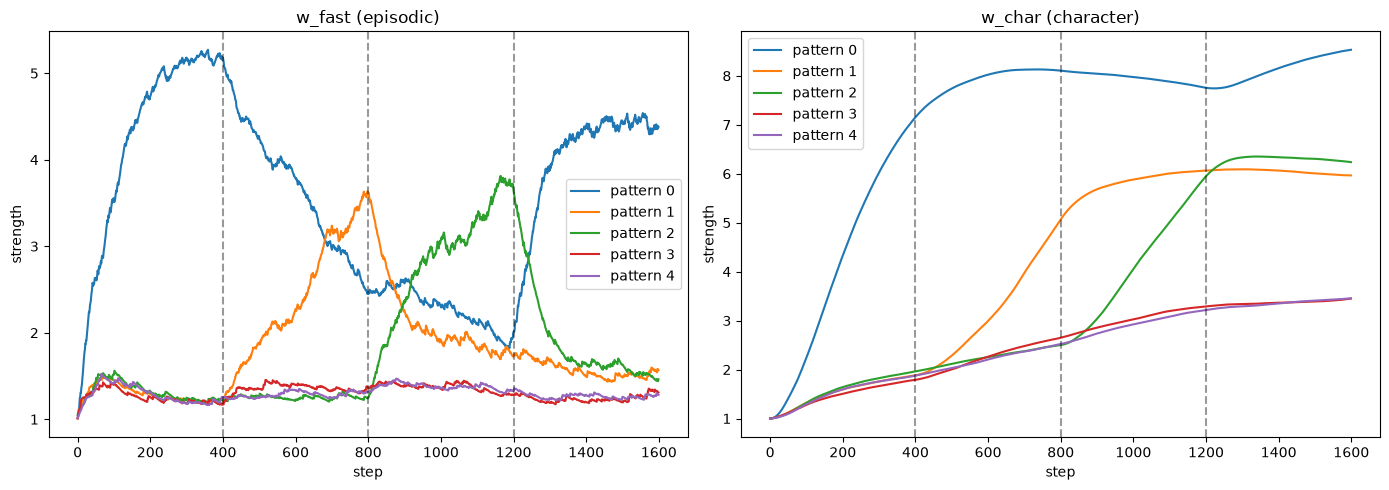

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i in range(n_patterns):
    axes[0].plot(fast_history[:, i].cpu().numpy(), label=f'pattern {i}')
    axes[1].plot(char_history[:, i].cpu().numpy(), label=f'pattern {i}')

for ax, title in zip(axes, ['w_fast (episodic)', 'w_char (character)']):
    for phase_end in [400, 800, 1200]:
        ax.axvline(x=phase_end, color='black', linestyle='--', alpha=0.4)
    ax.set_xlabel('step')
    ax.set_ylabel('strength')
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.savefig('two_layer_consolidation.png', dpi=100)
plt.show()

## Quantitative checks

1. **Persistence**: is `w_char[0]` at the end of phase 3 (before the return) still elevated
   above baseline (1.0), despite `w_fast[0]` having decayed back down? (tests against the
   decay=0.01 full-erasure failure mode)
2. **Plasticity**: did `w_char[1]` and `w_char[2]` actually rise during their own phases —
   i.e. is character strength still assignable to *new* patterns, not permanently locked to
   pattern 0? (tests against the decay=0.001 permanent-primacy-lock failure mode)
3. **Savings**: does pattern 0 re-cross a fixed `w_fast` threshold *faster* during phase 4
   (return) than it did during phase 1 (original learning)? Classic relearning-savings signature.

In [8]:
phase_bounds = [0, 400, 800, 1200, 1600]

char_end_phase3 = char_history[phase_bounds[3]-1]
fast_end_phase3 = fast_history[phase_bounds[3]-1]
print("End of phase 3 (just before return to pattern 0):")
print("  w_fast:", fast_end_phase3)
print("  w_char:", char_end_phase3)
print(f"  w_char[0] baseline excess: {(char_end_phase3[0] - 1).item():.4f}"
      f"  (patterns 1-4 mean excess: {(char_end_phase3[1:] - 1).mean().item():.4f})")

End of phase 3 (just before return to pattern 0):
  w_fast: tensor([1.9920, 1.7256, 3.6767, 1.2799, 1.3259])
  w_char: tensor([7.7561, 6.0641, 5.9407, 3.2884, 3.2145])
  w_char[0] baseline excess: 6.7561  (patterns 1-4 mean excess: 3.6269)


In [9]:
char_peak_per_pattern = torch.stack([
    char_history[phase_bounds[p]:phase_bounds[p+1]].max(dim=0).values
    for p in range(n_phases)
])
print("Peak w_char reached during each pattern's own dominant phase:")
for p, label in enumerate(['phase1 (pat0)', 'phase2 (pat1)', 'phase3 (pat2)', 'phase4 (pat0 return)']):
    print(f"  {label}: pattern {p if p < 3 else 0} peak = {char_peak_per_pattern[p, p if p < 3 else 0].item():.4f}")

Peak w_char reached during each pattern's own dominant phase:
  phase1 (pat0): pattern 0 peak = 7.1462
  phase2 (pat1): pattern 1 peak = 5.0562
  phase3 (pat2): pattern 2 peak = 5.9407
  phase4 (pat0 return): pattern 0 peak = 8.5319


In [10]:
threshold = 1.5  # arbitrary "well learned" w_fast threshold

def steps_to_threshold(fast_col, start, end, threshold):
    segment = fast_col[start:end]
    hits = (segment >= threshold).nonzero()
    return hits[0].item() if len(hits) > 0 else None

steps_phase1 = steps_to_threshold(fast_history[:, 0], phase_bounds[0], phase_bounds[1], threshold)
steps_phase4 = steps_to_threshold(fast_history[:, 0], phase_bounds[3], phase_bounds[4], threshold)

print(f"Pattern 0: steps to reach w_fast>={threshold} in phase 1 (original learning): {steps_phase1}")
print(f"Pattern 0: steps to reach w_fast>={threshold} in phase 4 (return/relearning):  {steps_phase4}")
if steps_phase1 is not None and steps_phase4 is not None:
    print(f"Savings: {steps_phase1 - steps_phase4} fewer steps ({100*(steps_phase1-steps_phase4)/steps_phase1:.1f}% faster)")

Pattern 0: steps to reach w_fast>=1.5 in phase 1 (original learning): 14
Pattern 0: steps to reach w_fast>=1.5 in phase 4 (return/relearning):  0
Savings: 14 fewer steps (100.0% faster)
